<a href="https://colab.research.google.com/github/solomon7-data/Athlete/blob/main/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [649]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [650]:
data = pd.read_csv('https://raw.githubusercontent.com/solomon7-data/HIV_DATA1/main/HIV.csv', encoding='latin1')

In [651]:

data = data.transpose().reset_index()
data.columns = data.iloc[1]
data = data.iloc[2:]
df = data
data.head()

1,Unnamed: 1,Activity,HIV - HIV Testing Service provided,HIV Prevention and Control,Clients receiving HIV test results (at VCT),"< 1 year, Male","< 1 year, Female","1 - 4 years, Male","1 - 4 years, Female","5 - 9 Years, Male",...,Number treated for Hepatitis B,"< 15 Years, Male","< 15 Years, Female",">= 15 Years, Male",">= 15 Years, Female",Number treated for Hepatitis C,"< 15 Years, Male","< 15 Years, Female",">= 15 Years, Male",">= 15 Years, Female"
2,Unnamed: 2,Meskerem 2018,1,NaN,134,NaN,NaN,NaN,NaN,NaN,...,25,NaN,NaN,11,14,10,NaN,1,7,2
3,Unnamed: 3,Tikemet 2018,1,NaN,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unnamed: 4,Hidar 2018,1,NaN,107,NaN,NaN,NaN,NaN,NaN,...,2,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
5,Unnamed: 5,Tahesas 2018,1,NaN,144,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Unnamed: 6,Tir 2018,1,NaN,118,NaN,NaN,NaN,NaN,NaN,...,19,19,NaN,NaN,NaN,2,2,NaN,NaN,NaN


In [652]:
df = data

In [653]:
rename_cols = {'Activity':'yr_mnth',
 'Clients receiving HIV test results (at VCT)':'VCT',
 'Clients testing positive for HIV (at VCT)':'VCT_Pos',
 'Clients receiving HIV test results (at PITC)':'PITC',
 'Clients testing positive for HIV (at PITC)':'PITC_Pos',
 'Number of index cases offered':'ICT_offered',
 'Number of contacts elicited':'Elicited',
 'Number of contacts tested':'ICT_Testd',
 'New positive':'ICT_Pos',
 'Known positive':'ICT_known',
 'HIV_Number of Individual HIV self test KIT distributed':'Self_Test',
 'HIV_Children currently on ART':'COA_Adult',
 'HIV_Adults currently on ART':'COA_Pedy',
 'HIV_Number of children (<19) who are currently on ART by regimen type':'COA_<19',
 'Number of adults and children with HIV infection newly started on ART':'TX_New',
 'Linkage outcome of newly identified Hiv positive individuals in the reporting period':'Linked',
 'Linked to Care and Treatment':'Initiated',
 'Known on ART':'known',
 'Lost to follow-up':'Lost',
 'Number of adult and pediatric ART patients for whom viral load test result received in the reporting period':'VL_Recieved',
 'Total number of adult and paediatric ART patients with an undetectable viral load(<50 copies/ml) in the reporting period':'supressed',
 'Total number of adult and paediatric ART patients with low level viremia (50 -1000 copies/ml) in the reporting period':'LVL',
 'Total number of clients on 3MMD':'3MMD',
 'Total number of clients on ASM(6MMD)':'ASM(6MMD)',
 'Total number of clients on FTAR':'FTAR',
 'Total number of clients on CAG':'CAG',
 'Total number of clients on PCAD':'PCAD',
 'Total number of clients on Adolescent DSD':'Adolescent DSD',
 'Total number of clients on KP DSD':'KP DSD',
 'Total number of clients on MCH DSD':'MCH DSD',
 'Total number of clients on other types of DSD':'Other_DSD',
 'Total number of clients on Advanced HIV Disease Care Model':'AHD',
 'Commercial sex workers':'CSW_1',
 'PrEP Curr (Number of individuals that received oral PrEP during the reporting period)':'PrEP',
 'By age and Sex':'Prep_Curr',
 'Number of STI cases tested for HIV':'STI_HIV',
 'Number of STI cases tested positive for HIV':'STI_HIV_Pos',
 'Proportion of patients enrolled in HIV care who were screened for TB (FD)':'TB_Screened',
 'Number of NEWLY Enrolled ART clients who were screened for TB during the reporting period':'TB_Screened_new',
 'Screened Positive for TB':'Presumptive_TB',
 'HIV_Number of ART patients who started on a standard course of TB Preventive Treatment (TPT) in the reporting period':'TB_RX',
 'Cervical Cancer screening by type of test':'Cervical_screening',
 'Screened by VIA':'VIA',
 'Screened by HPV DNA':'HPV',
 'HIV_VIA Screening Result':'VIA_Result',
 'Normal cervix':'Negative',
 'Precancerous Lesion:':'Positive',
 'Suspecious cancerous Lesion:':'Suspected',
 'HPV DNA test positive:':'HPV_Pos',
 'HIV_Treatment of precancerous cervical lesion':'Cervical_Treatment',
 'Treatment with Cryotherapy':'Cryotherapy',
 'Treatment with ':'LEEP',
 'Treatment with Thermal Ablation/Thermocoagulation':'Thermocoagulation'}

In [654]:
df = df.rename(columns=rename_cols)
df = df.loc[:, ~df.columns.str.contains("Male|Female|years", case = False, na = False)]


In [655]:
cols_to_keep = [
 'yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 'Cervical_Treatment',
 'Cryotherapy',
 'Treatment with LEEP',
 'Thermocoagulation']

In [656]:
df = df[cols_to_keep]

In [657]:
df.head()

1,yr_mnth,VCT,VCT_Pos,PITC,PITC_Pos,ICT_offered,Elicited,ICT_Testd,ICT_Pos,ICT_known,...,HPV,VIA_Result,Normal cervix:,Positive,Suspected,HPV_Pos,Cervical_Treatment,Cryotherapy,Treatment with LEEP,Thermocoagulation
2,Meskerem 2018,134,1,716,4,41,62,16,NaN,4,...,NaN,59,56,3,NaN,NaN,3,NaN,2,1
3,Tikemet 2018,100,1,679,6,24,43,20,2,13,...,NaN,74,68,5,1,NaN,2,NaN,NaN,2
4,Hidar 2018,107,2,706,3,29,41,15,NaN,NaN,...,1,49,48,1,NaN,1,1,NaN,1,NaN
5,Tahesas 2018,144,5,741,6,45,58,44,2,NaN,...,NaN,7,5,2,NaN,NaN,1,NaN,NaN,1
6,Tir 2018,118,1,661,4,35,55,33,1,4,...,NaN,42,41,1,NaN,NaN,NaN,NaN,NaN,NaN


In [658]:
df.columns.to_list()

['yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Died',
 'Others',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'Discordant Couple',
 'CSW_1',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VI

In [659]:
df = df.loc[:, ~df.columns.duplicated()]

In [660]:
df.columns.to_list()

['yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 '

In [661]:
numeric = [
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 'Cervical_Treatment',
 'Cryotherapy',
 'Treatment with LEEP',
 'Thermocoagulation']

In [662]:
df[numeric] = df[numeric].apply(pd.to_numeric,errors='coerce')
df[['month','year']] = df['yr_mnth'].str.split(' ',expand = True)


In [663]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 2 to 14
Data columns (total 63 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   yr_mnth                                                                13 non-null     object 
 1   VCT                                                                    12 non-null     float64
 2   VCT_Pos                                                                11 non-null     float64
 3   PITC                                                                   12 non-null     float64
 4   PITC_Pos                                                               12 non-null     float64
 5   ICT_offered                                                            13 non-null     int64  
 6   Elicited                                                               13 non-null     int64

In [664]:
convert_month = {'Meskerem':'September',
 'Tikemet':'October',
 'Hidar':'November',
 'Tahesas': 'December',
 'Tir': 'January',
 'Yekatit':'February',
 'Megabit': 'March',
 'Miazia': 'April',
 'Genbot': 'May',
 'Sene': 'June',
 'Hamle': 'July',
 'Nehase': 'August'}

In [665]:
categories = df['month'].unique()
month_order = ['September', 'October', 'November', 'December','January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

In [666]:
df['month_gc'] = df['month'].map(convert_month)

df['month_gc'] = pd.Categorical(
    df['month_gc'],
    categories=month_order,
    ordered=True)



In [667]:
df['total_test'] = df['VCT'] + df['PITC']
df['total_pos'] = df['VCT_Pos'] + df['PITC_Pos']


/tmp/ipykernel_1232/3285338378.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('month_gc')['total_test'].sum().plot(
/tmp/ipykernel_1232/3285338378.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('month_gc')['total_pos'].sum().plot(kind='line',marker='o', color = '#E45756')
/tmp/ipykernel_1232/3285338378.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('month_gc')['VCT'].sum(

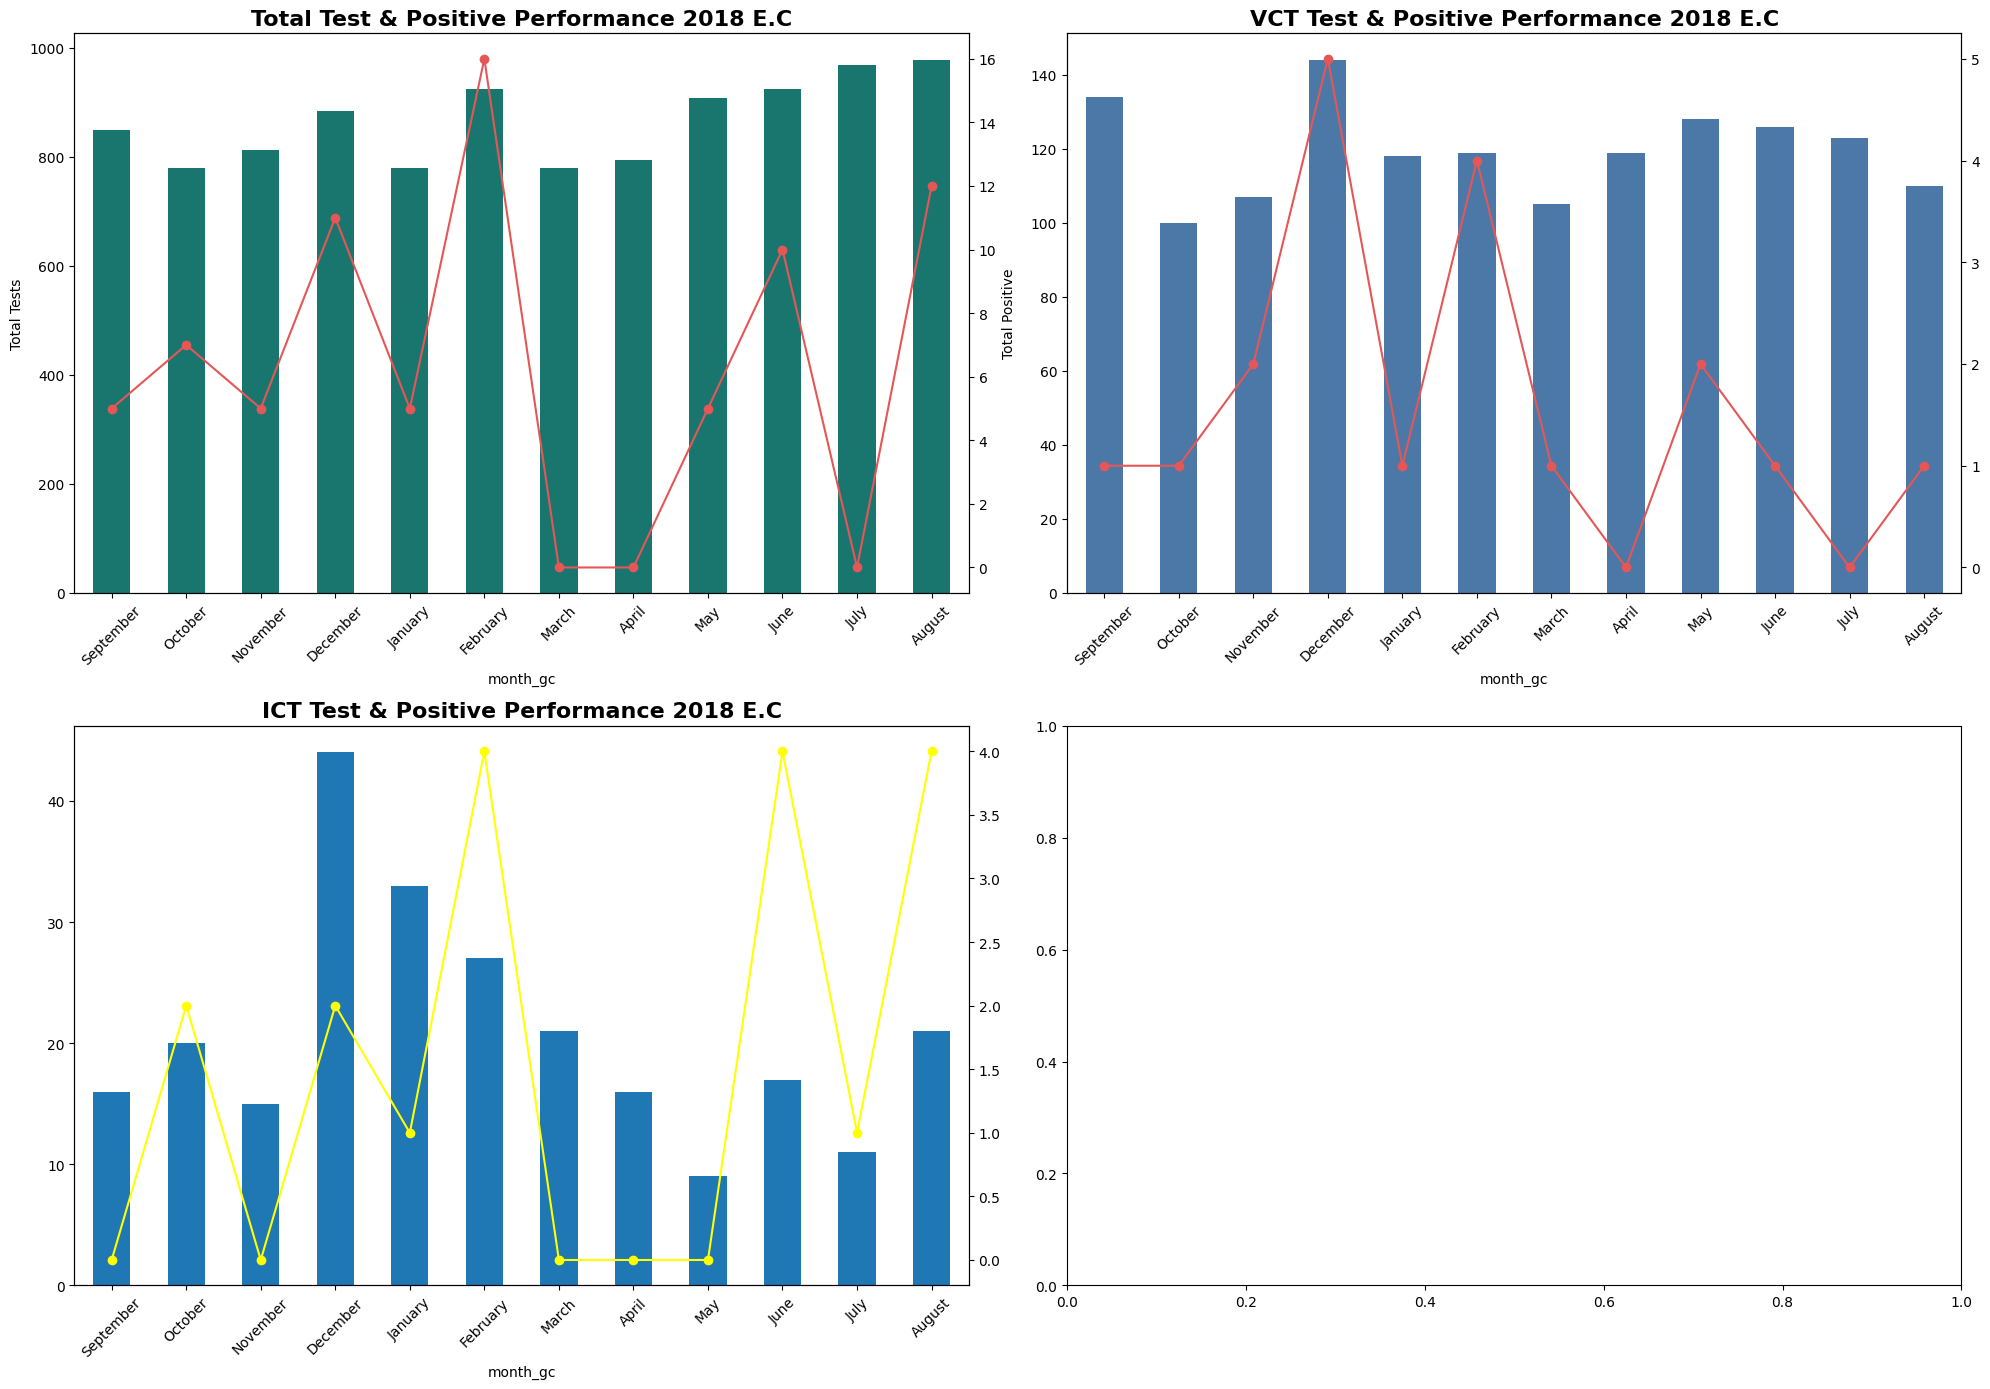

In [682]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Bar chart: Total tests
df.groupby('month_gc')['total_test'].sum().plot(
    kind='bar',ax=axes[0, 0],color = '#19766F')

# Create secondary y-axis
ax2 = axes[0, 0].twinx()

# Line chart: Total positive
df.groupby('month_gc')['total_pos'].sum().plot(kind='line',marker='o', color = '#E45756')

# Rotate month labels
axes[0, 0].tick_params(axis='x', rotation=45)

# Labels
axes[0, 0].set_ylabel('Total Tests')
ax2.set_ylabel('Total Positive')
ax2.set_title('Total Test & Positive Performance 2018 E.C',fontsize=16, fontweight='bold',fontname='Times New Roman')
#VCT
df.groupby('month_gc')['VCT'].sum().plot(kind='bar',ax=axes[0, 1],color ='#4C78A8')
ax2 = axes[0, 1].twinx()
df.groupby('month_gc')['VCT_Pos'].sum().plot(kind='line',marker='o', color = '#E45756')
axes[0, 1].tick_params(axis='x', rotation=45)
ax2.set_title('VCT Test & Positive Performance 2018 E.C',fontsize=16, fontweight='bold',fontname='Times New Roman')


#ICT
df.groupby('month_gc')['ICT_Testd'].sum().plot(kind='bar',ax=axes[1, 0])
ax2 = axes[1, 0].twinx()
df.groupby('month_gc')['ICT_Pos'].sum().plot(kind='line',marker='o', color = 'yellow')
axes[1, 0].tick_params(axis='x', rotation=45)

ax2.set_title('ICT Test & Positive Performance 2018 E.C',fontsize=16, fontweight='bold',fontname='Times New Roman')






plt.tight_layout()
plt.show()